In [607]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor


pd.set_option("display.max_columns", None)

## 1. Data Importing

In [608]:
FILE_PATH = "../data/202306.xlsx"
df = pd.read_excel(FILE_PATH)

df.head(5)

,room_id,project_id,post_name,condo_link,last_update,poster_name,poster_status,rental,rental_unit,deposit,deposit_unit,advance_payment,advance_payment_unit,room_description,building,facing,no_bedroom,floor,room_size,unit_type,air_conditioner,digital_door_lock,furnished,hot_tub,in_room_wifi,kitchen_hood,kitchen_stove,phone,refrigerator,tv,washer,water_heater,project_name
0,1,37,"🎊 For rent, Beat Bangwa Interchange, 1 bedroom...",https://propertyhub.in.th/en/listings/for-rent...,2023-06-09 12:34:52,NR-Agent สนใจคอนโด @Line ในรายละเอียดประกาศได้...,Verified member,10000,THB/month,Please,contact,Please,contact,"Please Contact , Tel : 0620672551 LINEID1 : @...",A,NaN,1 room,8th floor,27 sq.m.,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,Beat Bangwa Interchange
1,2,46,🎊 For rent Chewathai Petchkasem 27 STUDIO 24th...,https://propertyhub.in.th/en/listings/for-rent...,2023-06-09 12:34:52,NR-Agent สนใจคอนโด @Line ในรายละเอียดประกาศได้...,Verified member,9000,THB/month,Please,contact,Please,contact,"Please Contact , Tel : 0807924268 LINEID1 : @...",1,NaN,1 room,24th floor,24 sq.m.,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,Chewathai Phetkasem 27
2,3,169,"🎊 For rent, Supalai Park Ratchaphruek-Petchkas...",https://propertyhub.in.th/en/listings/for-rent...,2023-06-09 12:34:52,NR-Agent สนใจคอนโด @Line ในรายละเอียดประกาศได้...,Verified member,10000,THB/month,Please,contact,Please,contact,"Please Contact , Tel : 0620672551 LINEID1 : @...",1,NaN,1 room,27th floor,45 sq.m.,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,Supalai Park Ratchaphruek - Phetkasem
3,4,46,"🎊 For rent, Chewathai Petchkasem 27, 1 bedroom...",https://propertyhub.in.th/en/listings/for-rent...,2023-06-09 12:34:52,NR-Agent สนใจคอนโด @Line ในรายละเอียดประกาศได้...,Verified member,10000,THB/month,Please,contact,Please,contact,"Please Contact , Tel : 0620672551 LINEID1 : @...",1,NaN,1 room,4th floor,36 sq.m.,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,Chewathai Phetkasem 27
4,5,46,🎊 For rent Chewathai Phetkasem 27 1 bedroom 1 ...,https://propertyhub.in.th/en/listings/for-rent...,2023-06-09 12:34:52,NR-Agent สนใจคอนโด @Line ในรายละเอียดประกาศได้...,Verified member,11000,THB/month,Please,contact,Please,contact,"Please Contact , Tel : 0620672551 LINEID1 : @...",1,NaN,1 room,21st floor,26 sq.m.,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,Chewathai Phetkasem 27


In [609]:
print(df.columns)

Index(['room_id', 'project_id', 'post_name', 'condo_link', 'last_update',
       'poster_name', 'poster_status', 'rental', 'rental_unit', 'deposit',
       'deposit_unit', 'advance_payment', 'advance_payment_unit',
       'room_description', 'building', 'facing', 'no_bedroom', 'floor',
       'room_size', 'unit_type', 'air_conditioner', 'digital_door_lock',
       'furnished', 'hot_tub', 'in_room_wifi', 'kitchen_hood', 'kitchen_stove',
       'phone', 'refrigerator', 'tv', 'washer', 'water_heater',
       'project_name'],
      dtype='str')


In [610]:
selected_col = ["poster_status", "rental", "no_bedroom", "floor", "room_size", "unit_type", 
                "air_conditioner", "digital_door_lock", "furnished", "hot_tub", "in_room_wifi", "kitchen_hood", 
                "kitchen_stove", "phone", "refrigerator", "tv", "washer", "water_heater", "project_name"]

data = df[selected_col]

data.head(5)

,poster_status,rental,no_bedroom,floor,room_size,unit_type,air_conditioner,digital_door_lock,furnished,hot_tub,in_room_wifi,kitchen_hood,kitchen_stove,phone,refrigerator,tv,washer,water_heater,project_name
0,Verified member,10000,1 room,8th floor,27 sq.m.,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,Beat Bangwa Interchange
1,Verified member,9000,1 room,24th floor,24 sq.m.,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,Chewathai Phetkasem 27
2,Verified member,10000,1 room,27th floor,45 sq.m.,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,Supalai Park Ratchaphruek - Phetkasem
3,Verified member,10000,1 room,4th floor,36 sq.m.,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,Chewathai Phetkasem 27
4,Verified member,11000,1 room,21st floor,26 sq.m.,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,Chewathai Phetkasem 27


In [611]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10312 entries, 0 to 10311
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   poster_status      9539 non-null   str  
 1   rental             10312 non-null  int64
 2   no_bedroom         10268 non-null  str  
 3   floor              9820 non-null   str  
 4   room_size          10312 non-null  str  
 5   unit_type          10312 non-null  str  
 6   air_conditioner    10312 non-null  int64
 7   digital_door_lock  10312 non-null  int64
 8   furnished          10312 non-null  int64
 9   hot_tub            10312 non-null  int64
 10  in_room_wifi       10312 non-null  int64
 11  kitchen_hood       10312 non-null  int64
 12  kitchen_stove      10312 non-null  int64
 13  phone              10312 non-null  int64
 14  refrigerator       10312 non-null  int64
 15  tv                 10312 non-null  int64
 16  washer             10312 non-null  int64
 17  water_heater       1031

## 2. Data Cleaning

In [612]:
def clean_room_size(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).lower().strip()

    nums = re.findall(r"\d+\.?\d*", value)

    if nums:
        return float(nums[0])
    
    return np.nan

def clean_floor(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).lower().strip()

    if value in ["xx floor", "x floor", "xx", "-", "", "x", "nan"]:
        return np.nan
    
    value = value.replace("floor", "").strip()

    value = re.sub(r"(st|nd|rd|th)", "", value)

    value = value.replace("+", "").strip()

    if "-" in value:
        nums = re.findall(r"\d+", value)
        if len(nums) == 2:
            floor = (int(nums[0]) + int(nums[1])) / 2
            
            if floor <= 0:
                return np.nan

            return floor

    nums = re.findall(r"\d+", value)
    
    if len(nums) > 0:
        floor = int(nums[0])

        if floor <= 0:
            return np.nan
        
        return floor
    
    return np.nan

def clean_project_name(df, n=15):

    df = df.copy()

    df['project_name'] = df['project_name'].fillna("Unknown").astype(str).str.strip().str.replace(r"\s+", "", regex=True)
    
    counts = df['project_name'].value_counts()
    
    valid = counts[counts >= n].index

    df['project_name_grouped'] = df['project_name'].where(
        df['project_name'].isin(valid),
        "Other"
    )

    df = df.drop(columns='project_name')

    return df

def clean_poster_status(df):

    df = df.copy()
    df['poster_status'] = (df['poster_status']
                           .fillna("No Registered")
                           .astype(str)
                           .replace({
            "Verified member": "Verified",
            "Listing from Non verified member": "Non Verified"
        }))

    return df

def clean_no_bedroom(df):
    
    df = df.copy()

    df['no_bedroom'] = df['no_bedroom'].astype(str).str.replace("room", "", regex=False).str.strip()

    df['no_bedroom'] = pd.to_numeric(df['no_bedroom'], errors='coerce')

    df['no_bedroom'] = df['no_bedroom'].fillna(0)

    return df    

In [613]:
data["room_size"] = data["room_size"].apply(clean_room_size)
data = data[(data["room_size"] >= 10) & (data["room_size"] <= 1000)]

data['floor'] = data['floor'].apply(clean_floor)
data['floor'] = data['floor'].fillna(data['floor'].median())

data = clean_project_name(data)
data["project_name_grouped"] = data['project_name_grouped'].fillna("Others").astype(str).str.strip()

data = clean_poster_status(data)
data['poster_status'] = data['poster_status'].fillna("No Registered")

data = clean_no_bedroom(data)
data['no_bedroom'] = data['no_bedroom'].fillna(0)

data = data.drop_duplicates()

data.head(10)

,poster_status,rental,no_bedroom,floor,room_size,unit_type,air_conditioner,digital_door_lock,furnished,hot_tub,in_room_wifi,kitchen_hood,kitchen_stove,phone,refrigerator,tv,washer,water_heater,project_name_grouped
0,Verified,10000,1.0,8.0,27.0,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,BeatBangwaInterchange
1,Verified,9000,1.0,24.0,24.0,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,ChewathaiPhetkasem27
2,Verified,10000,1.0,27.0,45.0,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,SupalaiParkRatchaphruek-Phetkasem
3,Verified,10000,1.0,4.0,36.0,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,ChewathaiPhetkasem27
4,Verified,11000,1.0,21.0,26.0,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,ChewathaiPhetkasem27
5,Verified,11000,1.0,8.0,46.0,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,SupalaiParkRatchaphruek-Phetkasem
6,Verified,9000,1.0,8.0,24.0,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,ChewathaiPhetkasem27
7,Verified,10000,1.0,15.0,23.5,Studio,1,0,1,0,1,0,0,0,1,1,0,1,ChewathaiPhetkasem27
8,Verified,13000,1.0,33.0,46.0,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,SupalaiParkRatchaphruek-Phetkasem
9,Verified,8500,1.0,11.0,24.0,1 Bedroom,1,0,1,0,0,0,0,0,0,0,0,1,ChewathaiPhetkasem27


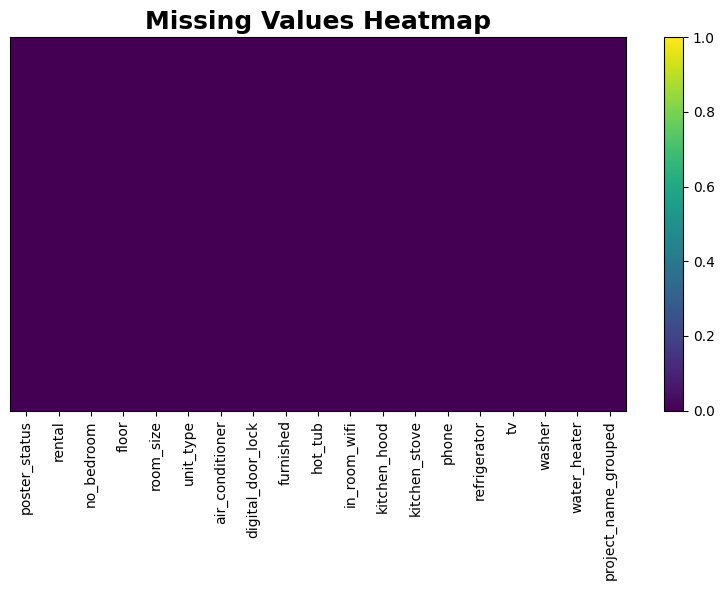

In [614]:
import matplotlib.pyplot as plt

na_matrix = data.isna()

plt.figure(figsize=(8, 6))
im = plt.imshow(
    na_matrix.values,
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.xticks(
    range(len(na_matrix.columns)),
    na_matrix.columns,
    rotation=90
)

plt.yticks([])
plt.colorbar(im)
plt.title("Missing Values Heatmap", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [615]:
data['unit_type'].unique()

<ArrowStringArray>
[       '1 Bedroom',           'Studio',        '2 Bedroom',
 'Duplex 1 Bedroom',        '3 Bedroom',             'Moff',
 'Duplex 2 Bedroom', 'Duplex 3 Bedroom',        '4 Bedroom',
        'Penthouse', 'Duplex 4 Bedroom']
Length: 11, dtype: str

## 3. Feature Engineering

In [616]:
amenity_cols = ["air_conditioner", "digital_door_lock", "furnished", "hot_tub", "in_room_wifi", "kitchen_hood", 
                "kitchen_stove", "phone", "refrigerator", "tv", "washer", "water_heater"]

data['amenity_counts'] = data[amenity_cols].sum(axis=1)

data['kitchen_ready'] = (data['kitchen_stove'] + data['kitchen_hood'] + data['refrigerator'])
data["move_in_ready"] = (data['furnished'] + data['air_conditioner'] + data['refrigerator'] + data['washer'])
data["comfort_score"] = (data["tv"] + data["in_room_wifi"] + data["air_conditioner"])

data['room_size_group'] = pd.cut(data['room_size'], bins=[0,25,35,50,80,150,np.inf], labels=["XS", "S", "M", "L", "XL", "XXL"])

proj_counts = data['project_name_grouped'].value_counts()

data['project_counts'] = data["project_name_grouped"].map(proj_counts)

data['is_popular_project'] = ((data["project_counts"] >= 100) & (data['project_name_grouped'] != "Other")).astype(int)

data = data.drop(columns=amenity_cols)
data = data.drop(columns='project_counts')

data.head()

,poster_status,rental,no_bedroom,floor,room_size,unit_type,project_name_grouped,amenity_counts,kitchen_ready,move_in_ready,comfort_score,room_size_group,is_popular_project
0,Verified,10000,1.0,8.0,27.0,1 Bedroom,BeatBangwaInterchange,3,0,2,1,S,0
1,Verified,9000,1.0,24.0,24.0,1 Bedroom,ChewathaiPhetkasem27,3,0,2,1,XS,0
2,Verified,10000,1.0,27.0,45.0,1 Bedroom,SupalaiParkRatchaphruek-Phetkasem,3,0,2,1,M,0
3,Verified,10000,1.0,4.0,36.0,1 Bedroom,ChewathaiPhetkasem27,3,0,2,1,M,0
4,Verified,11000,1.0,21.0,26.0,1 Bedroom,ChewathaiPhetkasem27,3,0,2,1,S,0


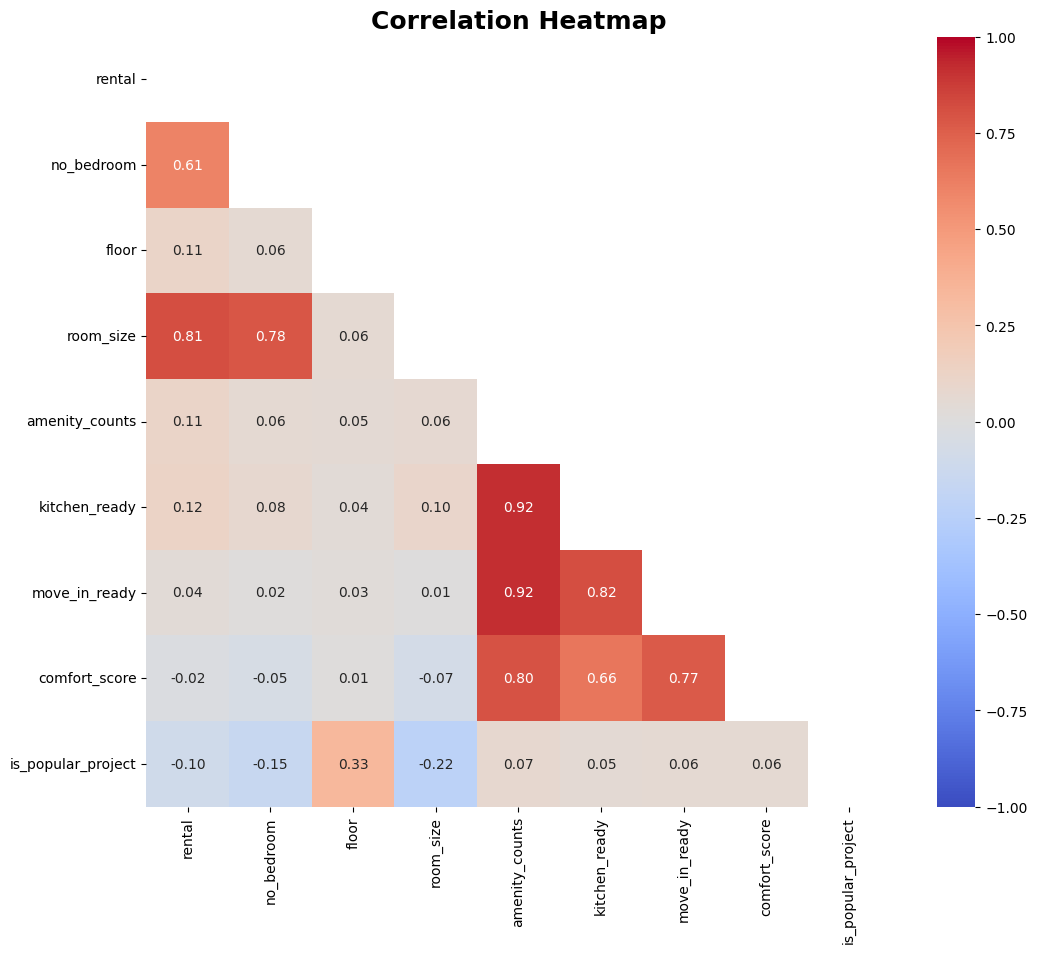

In [617]:
numeric_df = data.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap", fontsize=18, fontweight='bold')
plt.show()

## 4. Training

In [ ]:
target = 'rental'

X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10), categorical_features)
    ],
    remainder="drop"
)
    
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.0001, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "VotingRegressor": VotingRegressor(
        estimators=[
            ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
            ('svr', SVR(C=10, epsilon=0.1, kernel='rbf'))
        ],
        weights=[0.7, 0.3], n_jobs=-1
    )
}

results = []
best_model = None
best_model_name = None
best_r2 = -np.inf

for name, regressor in tqdm(models.items(), desc="Model Training"):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", regressor)
    ])

    model = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Models": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_model_name = name



C:\Users\kim_c\AppData\Local\Temp\ipykernel_18728\619263223.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns
Model Training: 100%|██████████| 9/9 [00:28<00:00,  3.21s/it]

              Models          MAE          RMSE        R2
8    VotingRegressor  4477.848448  10231.509717  0.910556
4      Random Forest  4637.176253  11321.848845  0.890477
6                SVR  5116.635510  11581.652773  0.885393
0  Linear Regression  5385.919750  13278.829318  0.849343
5  Gradient Boosting  7084.889668  13580.777003  0.842414
2   Lasso Regression  5460.315948  14005.005066  0.832415
1   Ridge Regression  5465.986141  14023.898817  0.831962
7                KNN  7684.833921  15364.210582  0.798307
3      Decision Tree  6511.379583  20360.320431  0.645808


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False)

print(results_df)

              Models          MAE          RMSE        R2
8    VotingRegressor  4477.848448  10231.509717  0.910556
4      Random Forest  4637.176253  11321.848845  0.890477
6                SVR  5116.635510  11581.652773  0.885393
0  Linear Regression  5385.919750  13278.829318  0.849343
5  Gradient Boosting  7084.889668  13580.777003  0.842414
2   Lasso Regression  5460.315948  14005.005066  0.832415
1   Ridge Regression  5465.986141  14023.898817  0.831962
7                KNN  7684.833921  15364.210582  0.798307
3      Decision Tree  6511.379583  20360.320431  0.645808
